In [1]:
from pymongo import MongoClient
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

###  a. Create collections “flights” inside database “airline_delayDB”


In [2]:
def mongoimport (csv_path):
    
    flight_df = pd.read_csv(csv_path)
    
    payload = json.loads(flight_df.to_json(orient='records'))
    
    collection.delete_many({})
    collection.insert_many(payload)
    

if __name__ == "__main__":
    print("welcom to pymongo")
    client = MongoClient("mongodb://localhost:27017")
    print(client)
    db = client['airline_delayDB']
    collection = db['flights']
    mongoimport('C:/PyMongo/Flights_Delay.csv')

welcom to pymongo
MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True)


### b. Average arrival delay caused by airlines

In [3]:
avg_arrival_delay = collection.aggregate([
        {'$group' : {'_id' : 'null', 'avg arrival_delay':{ '$avg' : '$ARRIVAL_DELAY'}}}, 
                    {'$project' : {'_id' : 0}}])
for item in avg_arrival_delay:
        item['avg arrival_delay'] = np.round(item['avg arrival_delay'], 2) 
        print(item)

{'avg arrival_delay': 7.55}


### c. Days of months with respect to average of arrival delays. [Create a suitable plot using matplotlib/seaborn] 

In [4]:
avg_arrival_delay = collection.aggregate([
        {'$group' : {'_id' : '$DAY', 'avg arrival_delay':{ '$avg' : '$ARRIVAL_DELAY'}}}])
list1 = []
for item in avg_arrival_delay:
        item['avg arrival_delay'] = np.round(item['avg arrival_delay'], 2) 
        #print(item)
        list1.append(item)
print(list1)

[{'_id': 31, 'avg arrival_delay': -1.2}, {'_id': 22, 'avg arrival_delay': 6.55}, {'_id': 13, 'avg arrival_delay': 3.38}, {'_id': 18, 'avg arrival_delay': 3.57}, {'_id': 20, 'avg arrival_delay': 3.88}, {'_id': 25, 'avg arrival_delay': 4.9}, {'_id': 28, 'avg arrival_delay': 3.26}, {'_id': 9, 'avg arrival_delay': 4.42}, {'_id': 17, 'avg arrival_delay': 8.76}, {'_id': 27, 'avg arrival_delay': 4.71}, {'_id': 10, 'avg arrival_delay': -0.05}, {'_id': 6, 'avg arrival_delay': 10.61}, {'_id': 23, 'avg arrival_delay': 4.21}, {'_id': 21, 'avg arrival_delay': 6.92}, {'_id': 3, 'avg arrival_delay': 18.14}, {'_id': 4, 'avg arrival_delay': 17.16}, {'_id': 5, 'avg arrival_delay': 16.24}, {'_id': 24, 'avg arrival_delay': 5.74}, {'_id': 14, 'avg arrival_delay': 1.33}, {'_id': 15, 'avg arrival_delay': 2.97}, {'_id': 30, 'avg arrival_delay': 4.47}, {'_id': 12, 'avg arrival_delay': 11.25}, {'_id': 16, 'avg arrival_delay': 9.12}, {'_id': 29, 'avg arrival_delay': 0.08}, {'_id': 1, 'avg arrival_delay': 14.81},

In [5]:
df = pd.DataFrame(list1).sort_values(by=['_id'])
df

,_id,avg arrival_delay
24,1,14.81
25,2,15.05
14,3,18.14
15,4,17.16
16,5,16.24
11,6,10.61
26,7,2.83
28,8,5.23
7,9,4.42
10,10,-0.05


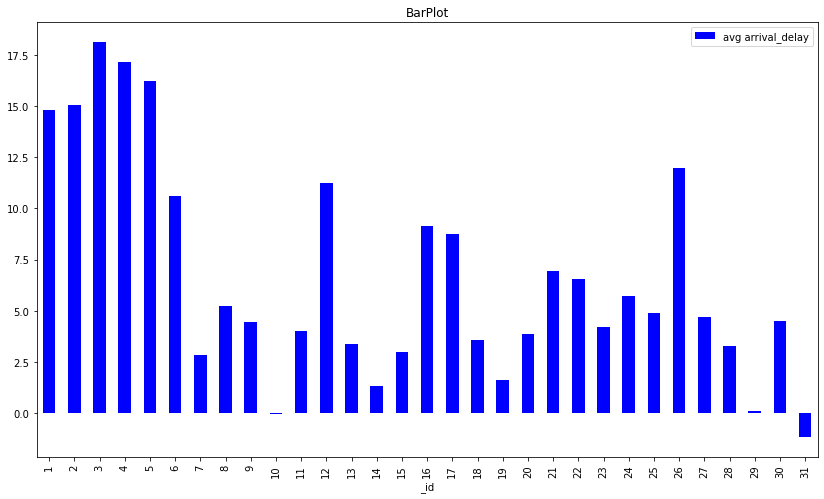

In [6]:
df.plot(kind = 'bar',
        x = '_id',
        y = 'avg arrival_delay',
        color = 'blue',figsize=(14,8))
plt.title('BarPlot')
plt.show()

### d. Arrange weekdays with respect to the average arrival delays caused. [Create a suitable plot using matplotlib/seaborn]

In [7]:
avg_arrival_delay = collection.aggregate([
        {'$group' : {'_id' : '$DAY_OF_WEEK', 'avg arrival_delay':{ '$avg' : '$ARRIVAL_DELAY'}}}])
list2 = []
for item in avg_arrival_delay:
        item['avg arrival_delay'] = np.round(item['avg arrival_delay'], 2) 
        #print(item)
        list2.append(item)
print(list2)

[{'_id': 1, 'avg arrival_delay': 10.81}, {'_id': 4, 'avg arrival_delay': 7.17}, {'_id': 3, 'avg arrival_delay': 5.59}, {'_id': 7, 'avg arrival_delay': 10.11}, {'_id': 5, 'avg arrival_delay': 6.01}, {'_id': 2, 'avg arrival_delay': 8.03}, {'_id': 6, 'avg arrival_delay': 4.89}]


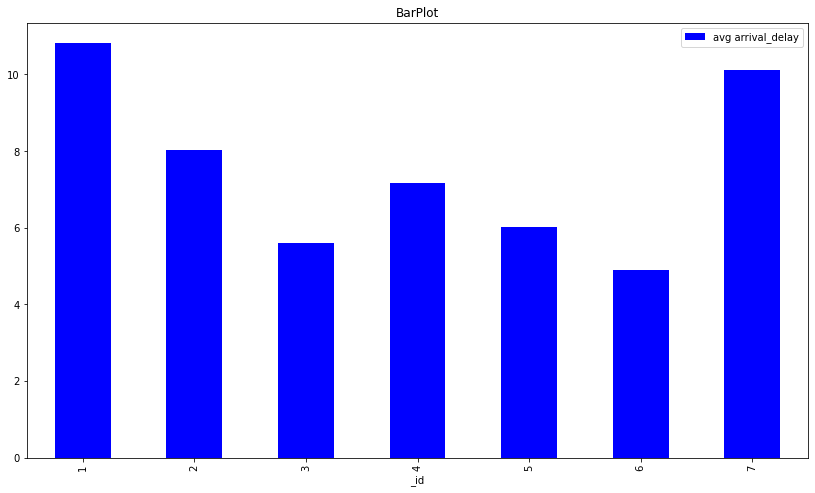

In [8]:
df1 = pd.DataFrame(list2).sort_values(by=['_id'])
#df1
df1.plot(kind = 'bar',x = '_id',y = 'avg arrival_delay',color = 'blue',figsize=(14,8))
plt.title('BarPlot')
plt.show()

### e.Arrange Days of month as per cancellations done in descending order.  [Create a suitable plot using matplotlib/seaborn]

In [9]:
cancellation = collection.aggregate([{'$match':{'CANCELLED':1}},
    {'$group':{'_id':'$DAY','CANCELLED':{'$count':{} } }  },
                                          {'$sort': { 'CANCELLED': -1 } }])
list3=[]
for item in cancellation:
    #print(item)
    list3.append(item)
print(list3)

[{'_id': 1, 'CANCELLED': 237}, {'_id': 5, 'CANCELLED': 215}, {'_id': 2, 'CANCELLED': 195}, {'_id': 27, 'CANCELLED': 185}, {'_id': 26, 'CANCELLED': 114}, {'_id': 4, 'CANCELLED': 113}, {'_id': 28, 'CANCELLED': 98}, {'_id': 9, 'CANCELLED': 89}, {'_id': 3, 'CANCELLED': 88}, {'_id': 15, 'CANCELLED': 83}, {'_id': 23, 'CANCELLED': 69}, {'_id': 16, 'CANCELLED': 63}, {'_id': 25, 'CANCELLED': 61}, {'_id': 21, 'CANCELLED': 61}, {'_id': 8, 'CANCELLED': 61}, {'_id': 17, 'CANCELLED': 59}, {'_id': 24, 'CANCELLED': 57}, {'_id': 6, 'CANCELLED': 53}, {'_id': 22, 'CANCELLED': 41}, {'_id': 7, 'CANCELLED': 31}, {'_id': 14, 'CANCELLED': 30}, {'_id': 10, 'CANCELLED': 27}, {'_id': 11, 'CANCELLED': 24}, {'_id': 20, 'CANCELLED': 21}, {'_id': 12, 'CANCELLED': 20}, {'_id': 13, 'CANCELLED': 14}, {'_id': 18, 'CANCELLED': 14}, {'_id': 19, 'CANCELLED': 9}, {'_id': 31, 'CANCELLED': 9}, {'_id': 30, 'CANCELLED': 7}, {'_id': 29, 'CANCELLED': 3}]


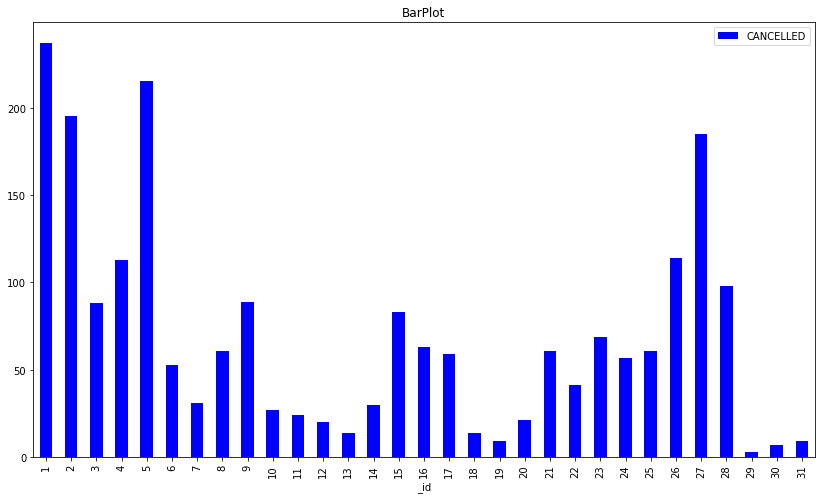

In [10]:
df3 = pd.DataFrame(list3).sort_values(by=['_id'])
#df1
df3.plot(kind = 'bar',x = '_id',y = 'CANCELLED',color = 'blue',figsize=(14,8))
plt.title('BarPlot')
plt.show()

### f.Find the busiest airports with respect to day of week. Create a suitable plot using matplotlib/seaborn.

In [58]:
busyairport = collection.aggregate([{'$group':{'_id':{'DAY_OF_WEEK':'$DAY_OF_WEEK','DESTINATION_AIRPORT':'$DESTINATION_AIRPORT'},
                                               'DESTINATION_AIRPORT':{'$count':{}}}},{'$sort':{'DESTINATION_AIRPORT':-1}}
                                   ])
for item in busyairport:
    print(item)

{'_id': {'DAY_OF_WEEK': 5, 'DESTINATION_AIRPORT': 'ATL'}, 'DESTINATION_AIRPORT': 644}
{'_id': {'DAY_OF_WEEK': 4, 'DESTINATION_AIRPORT': 'ATL'}, 'DESTINATION_AIRPORT': 557}
{'_id': {'DAY_OF_WEEK': 1, 'DESTINATION_AIRPORT': 'ATL'}, 'DESTINATION_AIRPORT': 551}
{'_id': {'DAY_OF_WEEK': 7, 'DESTINATION_AIRPORT': 'ATL'}, 'DESTINATION_AIRPORT': 522}
{'_id': {'DAY_OF_WEEK': 2, 'DESTINATION_AIRPORT': 'ATL'}, 'DESTINATION_AIRPORT': 485}
{'_id': {'DAY_OF_WEEK': 3, 'DESTINATION_AIRPORT': 'ATL'}, 'DESTINATION_AIRPORT': 480}
{'_id': {'DAY_OF_WEEK': 5, 'DESTINATION_AIRPORT': 'DFW'}, 'DESTINATION_AIRPORT': 447}
{'_id': {'DAY_OF_WEEK': 5, 'DESTINATION_AIRPORT': 'ORD'}, 'DESTINATION_AIRPORT': 442}
{'_id': {'DAY_OF_WEEK': 1, 'DESTINATION_AIRPORT': 'DFW'}, 'DESTINATION_AIRPORT': 420}
{'_id': {'DAY_OF_WEEK': 1, 'DESTINATION_AIRPORT': 'ORD'}, 'DESTINATION_AIRPORT': 408}
{'_id': {'DAY_OF_WEEK': 4, 'DESTINATION_AIRPORT': 'DFW'}, 'DESTINATION_AIRPORT': 406}
{'_id': {'DAY_OF_WEEK': 6, 'DESTINATION_AIRPORT': 'ATL

### g.Find top 10 Airlines of US. Create a suitable plot using matplotlib/seaborn

In [12]:
Airlines = collection.aggregate([{'$group':{'_id':'$AIRLINE',
                                        'AIRLINE':{'$count':{} } }  },
                                          {'$sort': { 'AIRLINE': -1 } },{'$limit':10}])
list4=[]
for item in Airlines:
    #print(item)
    list4.append(item)
print(list4)

[{'_id': 'WN', 'AIRLINE': 11738}, {'_id': 'DL', 'AIRLINE': 7989}, {'_id': 'EV', 'AIRLINE': 5916}, {'_id': 'OO', 'AIRLINE': 5708}, {'_id': 'AA', 'AIRLINE': 5250}, {'_id': 'UA', 'AIRLINE': 4701}, {'_id': 'US', 'AIRLINE': 3925}, {'_id': 'MQ', 'AIRLINE': 3502}, {'_id': 'B6', 'AIRLINE': 2548}, {'_id': 'AS', 'AIRLINE': 1586}]


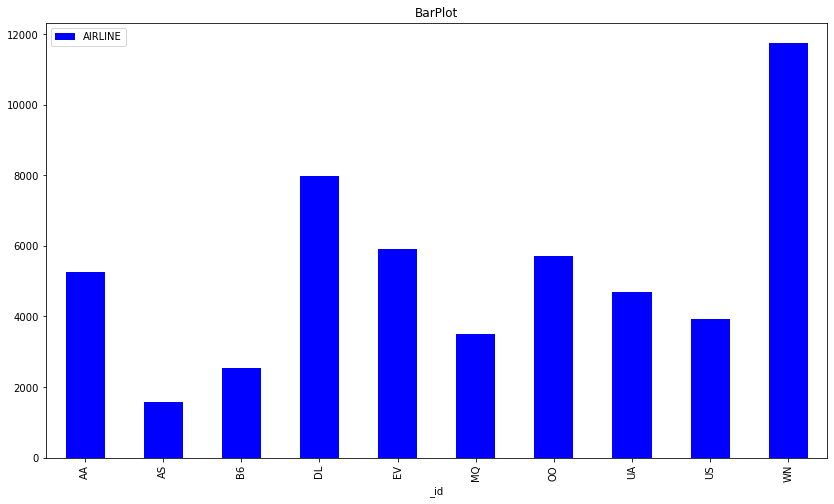

In [13]:
df4 = pd.DataFrame(list4).sort_values(by=['_id'])
#df1
df4.plot(kind = 'bar',x = '_id',y = 'AIRLINE',color = 'blue',figsize=(14,8))
plt.title('BarPlot')
plt.show()

### h.Finding airlines that make the maximum, minimum number of cancellations

In [14]:
min_maxcancellation = collection.aggregate([
        {'$group' : {'_id' : '$AIRLINE', 'maxcancellation':{ '$max' : '$CANCELLED'}, 
                    'mincancellation' : {'$min':'$CANCELLED'}}}])
for item in min_maxcancellation:
    print(item)

{'_id': 'B6', 'maxcancellation': 1, 'mincancellation': 0}
{'_id': 'OO', 'maxcancellation': 1, 'mincancellation': 0}
{'_id': 'DL', 'maxcancellation': 1, 'mincancellation': 0}
{'_id': 'WN', 'maxcancellation': 1, 'mincancellation': 0}
{'_id': 'F9', 'maxcancellation': 1, 'mincancellation': 0}
{'_id': 'AA', 'maxcancellation': 1, 'mincancellation': 0}
{'_id': 'EV', 'maxcancellation': 1, 'mincancellation': 0}
{'_id': 'HA', 'maxcancellation': 1, 'mincancellation': 0}
{'_id': 'AS', 'maxcancellation': 1, 'mincancellation': 0}
{'_id': 'VX', 'maxcancellation': 1, 'mincancellation': 0}
{'_id': 'US', 'maxcancellation': 1, 'mincancellation': 0}
{'_id': 'NK', 'maxcancellation': 1, 'mincancellation': 0}
{'_id': 'UA', 'maxcancellation': 1, 'mincancellation': 0}
{'_id': 'MQ', 'maxcancellation': 1, 'mincancellation': 0}


### i.Find and show airlines names in descending that make the most number of diversions made. [Create a suitable plot using matplotlib/seaborn]

In [15]:
airline_diversion = collection.aggregate([{'$match':{'DIVERTED':1}},
    {'$group':{'_id':'$AIRLINE','DIVERTED':{'$count':{} } }  },
                                          {'$sort': { 'DIVERTED': -1 } }])
list5=[]
for item in airline_diversion:
    #print(item)
    list5.append(item)
print(list5)

[{'_id': 'WN', 'DIVERTED': 35}, {'_id': 'OO', 'DIVERTED': 25}, {'_id': 'EV', 'DIVERTED': 22}, {'_id': 'DL', 'DIVERTED': 18}, {'_id': 'B6', 'DIVERTED': 16}, {'_id': 'AA', 'DIVERTED': 12}, {'_id': 'US', 'DIVERTED': 9}, {'_id': 'UA', 'DIVERTED': 8}, {'_id': 'MQ', 'DIVERTED': 5}, {'_id': 'HA', 'DIVERTED': 1}]


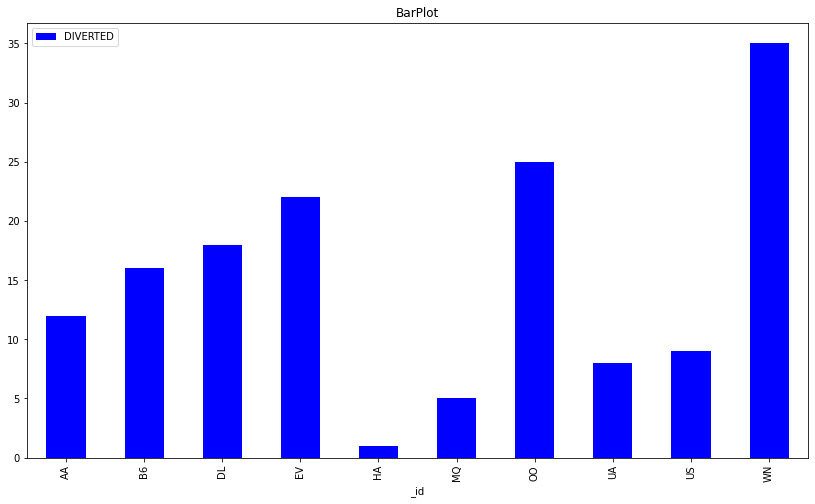

In [16]:
df5 = pd.DataFrame(list5).sort_values(by=['_id'])
#df1
df5.plot(kind = 'bar',x = '_id',y = 'DIVERTED',color = 'blue',figsize=(14,8))
plt.title('BarPlot')
plt.show()

### j.Finding days of month that see the most number of diversion

In [17]:
diversion = collection.aggregate([{'$match':{'DIVERTED':1}},
    {'$group':{'_id':'$DAY','DIVERTED':{'$count':{} } }  },
                                          {'$sort': { 'DIVERTED': -1 } }])
list6=[]
for item in diversion:
    #print(item)
    list6.append(item)
print(list6)
   

[{'_id': 2, 'DIVERTED': 15}, {'_id': 1, 'DIVERTED': 13}, {'_id': 4, 'DIVERTED': 12}, {'_id': 5, 'DIVERTED': 11}, {'_id': 9, 'DIVERTED': 9}, {'_id': 14, 'DIVERTED': 8}, {'_id': 6, 'DIVERTED': 7}, {'_id': 7, 'DIVERTED': 6}, {'_id': 23, 'DIVERTED': 6}, {'_id': 30, 'DIVERTED': 5}, {'_id': 11, 'DIVERTED': 5}, {'_id': 8, 'DIVERTED': 5}, {'_id': 18, 'DIVERTED': 5}, {'_id': 3, 'DIVERTED': 5}, {'_id': 21, 'DIVERTED': 4}, {'_id': 12, 'DIVERTED': 4}, {'_id': 16, 'DIVERTED': 4}, {'_id': 28, 'DIVERTED': 4}, {'_id': 20, 'DIVERTED': 4}, {'_id': 26, 'DIVERTED': 3}, {'_id': 31, 'DIVERTED': 3}, {'_id': 17, 'DIVERTED': 3}, {'_id': 27, 'DIVERTED': 3}, {'_id': 13, 'DIVERTED': 2}, {'_id': 15, 'DIVERTED': 1}, {'_id': 29, 'DIVERTED': 1}, {'_id': 19, 'DIVERTED': 1}, {'_id': 25, 'DIVERTED': 1}, {'_id': 10, 'DIVERTED': 1}]


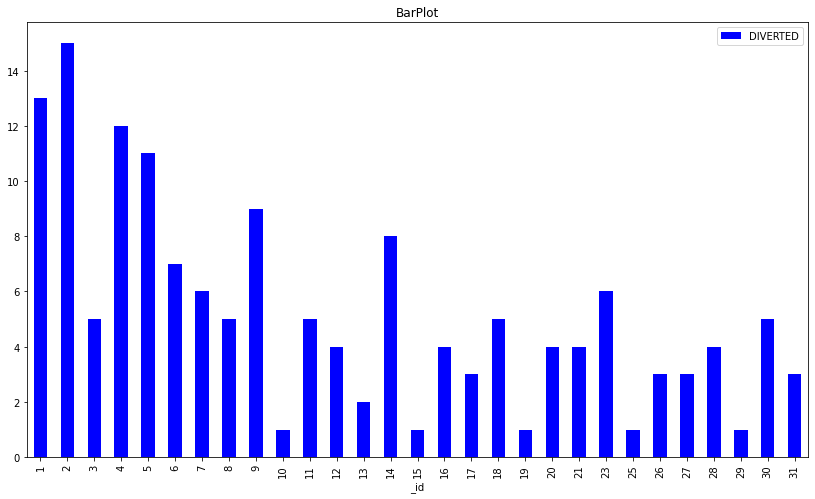

In [18]:
df6 = pd.DataFrame(list6).sort_values(by=['_id'])
#df1
df6.plot(kind = 'bar',x = '_id',y = 'DIVERTED',color = 'blue',figsize=(14,8))
plt.title('BarPlot')
plt.show()

### k.Calculating mean and standard deviation of departure delay for all flights in minutes

In [30]:
dep_delay = collection.aggregate([{'$group':{'_id':'$AIRLINE','stddev':{'$stdDevSamp':'$DEPARTURE_DELAY' },
                                            'mean':{ '$avg' : '$DEPARTURE_DELAY'} }  }
                                          ])
for item in sd_delay:
    print(item)


{'_id': 'EV', 'stddev': 40.60221351276123, 'mean': 11.534709861160556}
{'_id': 'HA', 'stddev': 30.282232449867873, 'mean': 1.1835883171070931}
{'_id': 'VX', 'stddev': 35.175272138214424, 'mean': 9.857142857142858}
{'_id': 'AA', 'stddev': 50.58770621277656, 'mean': 11.502293120638086}
{'_id': 'WN', 'stddev': 28.66211787470034, 'mean': 10.115161630358397}
{'_id': 'DL', 'stddev': 44.57836834851714, 'mean': 9.938812083973374}
{'_id': 'OO', 'stddev': 41.89825151163594, 'mean': 11.601510519690702}
{'_id': 'NK', 'stddev': 46.004490473829854, 'mean': 15.580739299610896}
{'_id': 'B6', 'stddev': 44.45221063284182, 'mean': 16.068664169787766}
{'_id': 'UA', 'stddev': 36.36679305829189, 'mean': 14.293129770992367}
{'_id': 'MQ', 'stddev': 43.46879359686756, 'mean': 17.07297384565709}
{'_id': 'F9', 'stddev': 55.21644901488805, 'mean': 23.514687100893997}
{'_id': 'US', 'stddev': 29.947392168792224, 'mean': 7.806271591815041}
{'_id': 'AS', 'stddev': 29.146560937464862, 'mean': 2.3365079365079366}


### l.Calculating mean and standard deviation of arrival delay for all flights in minutes

In [31]:
arr_delay = collection.aggregate([{'$group':{'_id':'$AIRLINE','stddev':{'$stdDevSamp':'$ARRIVAL_DELAY' },
                                            'mean':{ '$avg' : '$ARRIVAL_DELAY'} }  }
                                          ])
for item in arr_delay:
    print(item)

{'_id': 'OO', 'stddev': 43.76036682697073, 'mean': 10.154792043399638}
{'_id': 'B6', 'stddev': 47.64386997495004, 'mean': 13.95852534562212}
{'_id': 'WN', 'stddev': 31.22509472597743, 'mean': 3.697840458351697}
{'_id': 'DL', 'stddev': 46.95730281739293, 'mean': 2.8144726712856043}
{'_id': 'F9', 'stddev': 56.268044797487335, 'mean': 24.103448275862068}
{'_id': 'AA', 'stddev': 53.567708602545125, 'mean': 8.386631979187513}
{'_id': 'EV', 'stddev': 43.391999934340646, 'mean': 10.884270870655678}
{'_id': 'HA', 'stddev': 32.383300489670695, 'mean': 4.072423398328691}
{'_id': 'AS', 'stddev': 31.372826379244593, 'mean': -1.531766200762389}
{'_id': 'VX', 'stddev': 40.86556219200457, 'mean': 5.128571428571429}
{'_id': 'US', 'stddev': 34.10900474893442, 'mean': 5.977315185481719}
{'_id': 'NK', 'stddev': 47.57688184145277, 'mean': 14.206426484907498}
{'_id': 'UA', 'stddev': 38.96583521422199, 'mean': 6.697221614526362}
{'_id': 'MQ', 'stddev': 46.399985744813044, 'mean': 19.231592604605904}


### m.Create a partitioning table “flights_partition” using partitioned by schema “CANCELLED”

In [81]:
cancelled = collection.aggregate([{'$match':{'CANCELLED':1}},
    {'$group':{'_id':'$AIRLINE','CANCELLED':{'$count':{} } }  },
                                          {'$sort': { 'CANCELLED': -1 } }])
list7=[]
for item in cancelled:
    #print(item)
    list7.append(item)
print(list7)

[{'_id': 'MQ', 'CANCELLED': 414}, {'_id': 'WN', 'CANCELLED': 358}, {'_id': 'EV', 'CANCELLED': 312}, {'_id': 'AA', 'CANCELLED': 241}, {'_id': 'DL', 'CANCELLED': 177}, {'_id': 'US', 'CANCELLED': 169}, {'_id': 'OO', 'CANCELLED': 153}, {'_id': 'B6', 'CANCELLED': 145}, {'_id': 'UA', 'CANCELLED': 122}, {'_id': 'NK', 'CANCELLED': 21}, {'_id': 'VX', 'CANCELLED': 13}, {'_id': 'AS', 'CANCELLED': 12}, {'_id': 'F9', 'CANCELLED': 11}, {'_id': 'HA', 'CANCELLED': 3}]


In [83]:
df7 = pd.DataFrame(list7).sort_values(by=['_id'])
df7

,_id,CANCELLED
3,AA,241
11,AS,12
7,B6,145
4,DL,177
2,EV,312
12,F9,11
13,HA,3
0,MQ,414
9,NK,21
6,OO,153


### n.Finding all diverted Route from a source to destination Airport & which route is the most diverted route.

In [44]:
diversion = collection.aggregate([{'$match':{'DIVERTED':1}},
                                  {'$group':{'_id':{'ORIGIN_AIRPORT':'$ORIGIN_AIRPORT','destination':'$DESTINATION_AIRPORT'}}}
                                          ])
for item in diversion:
    print(item)
    #DIVERTED
    #DESTINATION_AIRPORT
    #ORIGIN_AIRPORT

{'_id': {'ORIGIN_AIRPORT': 'MCO', 'destination': 'ORD'}}
{'_id': {'ORIGIN_AIRPORT': 'COS', 'destination': 'ORD'}}
{'_id': {'ORIGIN_AIRPORT': 'DAL', 'destination': 'LGA'}}
{'_id': {'ORIGIN_AIRPORT': 'ORD', 'destination': 'LGA'}}
{'_id': {'ORIGIN_AIRPORT': 'JFK', 'destination': 'SAN'}}
{'_id': {'ORIGIN_AIRPORT': 'SFO', 'destination': 'SNA'}}
{'_id': {'ORIGIN_AIRPORT': 'ORD', 'destination': 'COS'}}
{'_id': {'ORIGIN_AIRPORT': 'JAN', 'destination': 'IAH'}}
{'_id': {'ORIGIN_AIRPORT': 'BOS', 'destination': 'SEA'}}
{'_id': {'ORIGIN_AIRPORT': 'AUS', 'destination': 'LAX'}}
{'_id': {'ORIGIN_AIRPORT': 'FLL', 'destination': 'BDL'}}
{'_id': {'ORIGIN_AIRPORT': 'IAH', 'destination': 'PHX'}}
{'_id': {'ORIGIN_AIRPORT': 'CLT', 'destination': 'MIA'}}
{'_id': {'ORIGIN_AIRPORT': 'PHL', 'destination': 'LAS'}}
{'_id': {'ORIGIN_AIRPORT': 'RSW', 'destination': 'BWI'}}
{'_id': {'ORIGIN_AIRPORT': 'RDU', 'destination': 'MIA'}}
{'_id': {'ORIGIN_AIRPORT': 'DSM', 'destination': 'ATL'}}
{'_id': {'ORIGIN_AIRPORT': 'BOS

In [50]:
most_diverted = collection.aggregate([{'$match':{'DIVERTED':1}},
                                  {'$group':{'_id':{'ORIGIN_AIRPORT':'$ORIGIN_AIRPORT','destination':'$DESTINATION_AIRPORT'},
                                             'DIVERTED':{'$count':{} }}},{'$sort':{'DIVERTED':-1}}
                                     ])
for item in most_diverted:
    print(item)

{'_id': {'ORIGIN_AIRPORT': 'STT', 'destination': 'PHL'}, 'DIVERTED': 2}
{'_id': {'ORIGIN_AIRPORT': 'HOU', 'destination': 'DAL'}, 'DIVERTED': 2}
{'_id': {'ORIGIN_AIRPORT': 'JFK', 'destination': 'EGE'}, 'DIVERTED': 2}
{'_id': {'ORIGIN_AIRPORT': 'PHL', 'destination': 'SAN'}, 'DIVERTED': 2}
{'_id': {'ORIGIN_AIRPORT': 'TPA', 'destination': 'LGA'}, 'DIVERTED': 2}
{'_id': {'ORIGIN_AIRPORT': 'JFK', 'destination': 'SEA'}, 'DIVERTED': 2}
{'_id': {'ORIGIN_AIRPORT': 'IAH', 'destination': 'ASE'}, 'DIVERTED': 2}
{'_id': {'ORIGIN_AIRPORT': 'CLT', 'destination': 'IAH'}, 'DIVERTED': 2}
{'_id': {'ORIGIN_AIRPORT': 'ORD', 'destination': 'ASE'}, 'DIVERTED': 2}
{'_id': {'ORIGIN_AIRPORT': 'SFO', 'destination': 'SNA'}, 'DIVERTED': 1}
{'_id': {'ORIGIN_AIRPORT': 'ORD', 'destination': 'LGA'}, 'DIVERTED': 1}
{'_id': {'ORIGIN_AIRPORT': 'JFK', 'destination': 'SAN'}, 'DIVERTED': 1}
{'_id': {'ORIGIN_AIRPORT': 'DAL', 'destination': 'LGA'}, 'DIVERTED': 1}
{'_id': {'ORIGIN_AIRPORT': 'FLL', 'destination': 'PVD'}, 'DIVERT

### o.When is the best time of day/day of week/time of a year to fly with minimum delays?

In [74]:
best_day = collection.aggregate([{'$group' : {'_id' : '$DAY', 'avg_delay':{ '$avg' : '$DEPARTURE_DELAY'}}},
                                {'$sort':{'avg_delay':-1}},{'$limit':1}])
for item in best_day:
    item['avg_delay'] = np.round(item['avg_delay'], 0)
    print("Best day to fly with minimum delays")
    print(item)

Best time of day with minimum delays
{'_id': 4, 'avg_delay': 19.0}


In [76]:
best_week = collection.aggregate([{'$group' : {'_id' : '$DAY_OF_WEEK', 'avg_delay':{ '$avg' : '$DEPARTURE_DELAY'}}},
                                 {'$sort':{'avg_delay':-1}},{'$limit':1}])
for item in best_week:
    item['avg_delay'] = np.round(item['avg_delay'], 0)
    print("Best day of week to fly with minimum delays")
    print(item)

Best day of week to fly with minimum delays
{'_id': 1, 'avg_delay': 14.0}


In [75]:
best_TimeOfYear = collection.aggregate([{'$group' : {'_id' : '$MONTH', 'avg_delay':{ '$avg' : '$DEPARTURE_DELAY'}}},
                                 {'$sort':{'avg_delay':-1}},{'$limit':1}])
for item in best_TimeOfYear:
    item['avg_delay'] = np.round(item['avg_delay'], 0)
    print("Best time of year to fly with minimum delays")
    print(item)

Best time of year to fly with minimum delays
{'_id': 3, 'avg_delay': 15.0}
